In [3]:
!pip install findspark -q

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
#import functions/Classes for sparkml
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.feature import StandardScaler

from pyspark.ml.clustering import KMeans
from pyspark.ml.feature import VectorAssembler

In [4]:
import findspark
findspark.init()

In [5]:
#Create SparkSession
#Ignore any warnings by SparkSession command

spark = SparkSession.builder.appName("Clustering using SparkML").getOrCreate()

In [6]:
#!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-BD0231EN-SkillsNetwork/datasets/customers.csv

--2026-02-20 14:16:52--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-BD0231EN-SkillsNetwork/datasets/customers.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8909 (8.7K) [text/csv]
Saving to: ‘customers.csv’

customers.csv       100%[===================>]   8.70K  --.-KB/s    in 0s      

2026-02-20 14:16:53 (113 MB/s) - ‘customers.csv’ saved [8909/8909]



In [7]:
# Load customers dataset
customer_data = spark.read.csv("customers.csv", header=True, inferSchema=True)

In [8]:
customer_data.show(5)

+----------+----+-------+-----------+
|Fresh_Food|Milk|Grocery|Frozen_Food|
+----------+----+-------+-----------+
|     12669|9656|   7561|        214|
|      7057|9810|   9568|       1762|
|      6353|8808|   7684|       2405|
|     13265|1196|   4221|       6404|
|     22615|5410|   7198|       3915|
+----------+----+-------+-----------+
only showing top 5 rows


In [9]:
feature_cols = ['Fresh_Food', 'Milk', 'Grocery', 'Frozen_Food']
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
customer_transformed_data = assembler.transform(customer_data)

In [11]:
customer_transformed_data.show(5)

+----------+----+-------+-----------+--------------------+
|Fresh_Food|Milk|Grocery|Frozen_Food|            features|
+----------+----+-------+-----------+--------------------+
|     12669|9656|   7561|        214|[12669.0,9656.0,7...|
|      7057|9810|   9568|       1762|[7057.0,9810.0,95...|
|      6353|8808|   7684|       2405|[6353.0,8808.0,76...|
|     13265|1196|   4221|       6404|[13265.0,1196.0,4...|
|     22615|5410|   7198|       3915|[22615.0,5410.0,7...|
+----------+----+-------+-----------+--------------------+
only showing top 5 rows


In [21]:
number_of_clusters = 3

kmeans = KMeans(k = number_of_clusters)

model = kmeans.fit(customer_transformed_data)

In [22]:
# Make predictions on the dataset
predictions = model.transform(customer_transformed_data)

In [23]:
# Display the results
predictions.show(5)

+----------+----+-------+-----------+--------------------+----------+
|Fresh_Food|Milk|Grocery|Frozen_Food|            features|prediction|
+----------+----+-------+-----------+--------------------+----------+
|     12669|9656|   7561|        214|[12669.0,9656.0,7...|         2|
|      7057|9810|   9568|       1762|[7057.0,9810.0,95...|         2|
|      6353|8808|   7684|       2405|[6353.0,8808.0,76...|         2|
|     13265|1196|   4221|       6404|[13265.0,1196.0,4...|         2|
|     22615|5410|   7198|       3915|[22615.0,5410.0,7...|         0|
+----------+----+-------+-----------+--------------------+----------+
only showing top 5 rows


In [24]:
predictions.groupBy('prediction').count().show()

+----------+-----+
|prediction|count|
+----------+-----+
|         1|   25|
|         2|  340|
|         0|   75|
+----------+-----+



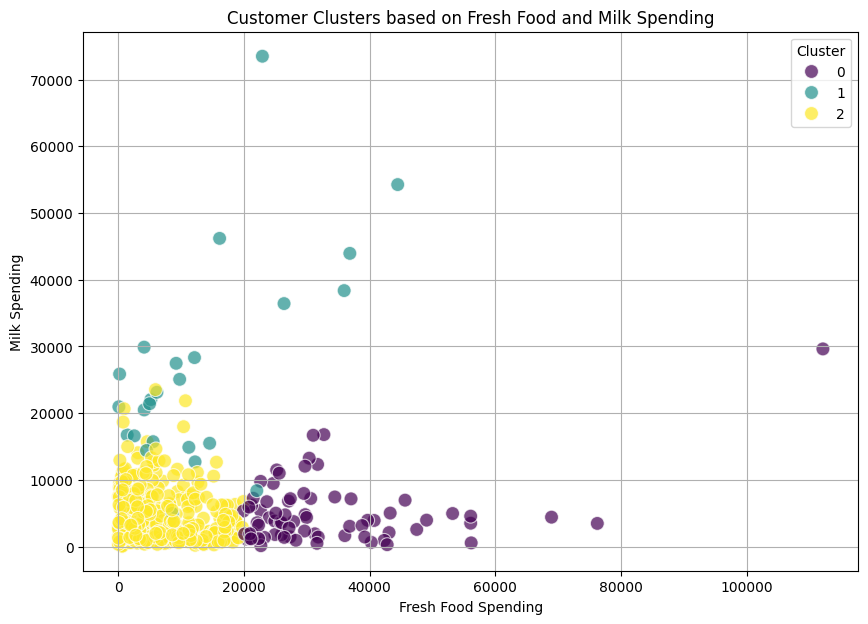

In [25]:
# Convert Spark DataFrame to Pandas DataFrame for plotting
pandas_predictions = predictions.toPandas()

# Create a scatter plot of Fresh_Food vs Milk, colored by prediction
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='Fresh_Food',
    y='Milk',
    hue='prediction',
    data=pandas_predictions,
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.title('Customer Clusters based on Fresh Food and Milk Spending')
plt.xlabel('Fresh Food Spending')
plt.ylabel('Milk Spending')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()